<a href="https://colab.research.google.com/github/muiddd/5thSemester_PCVK/blob/main/Week05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

NAMA : Abdul Muid
NIM : 244107020006 | N = 6
bins   : 32
clip   : 1.5
tile   : 4
L      : 2
WAKTU : 2026-09-29 19:44:14 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 4c94465d938be7c4


Text(0.5, 1.0, '244107020006 - CLAHE clip 1.5')

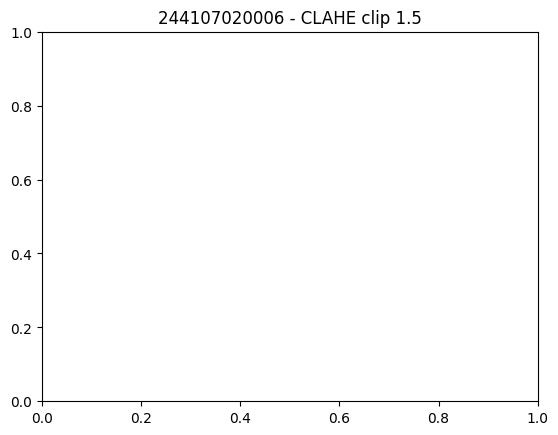

In [3]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Abdul Muid'
NIM = '244107020006'

N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

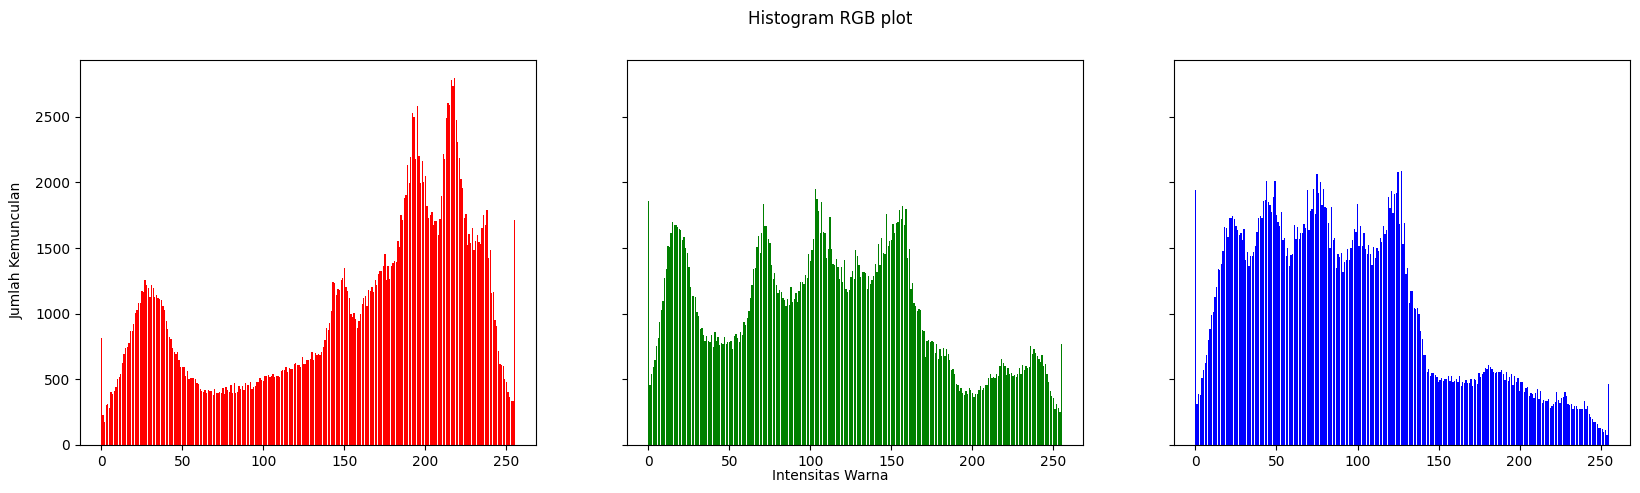

In [5]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [6]:
# Load gambar lena.jpg dalam format grayscale agar lebih mudah untuk perbandingan dasar
img_lena = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg', cv.IMREAD_GRAYSCALE)

# 1. Cara Manual (Looping tiap piksel)
hist_manual = np.zeros(256, dtype=int)
for y in range(img_lena.shape[0]):
    for x in range(img_lena.shape[1]):
        hist_manual[img_lena[y, x]] += 1

# 2. Cara NumPy
# flatten() digunakan untuk mengubah array 2D menjadi 1D agar bisa dihitung histogramnya
hist_np, _ = np.histogram(img_lena.flatten(), bins=256, range=[0, 256])

# 3. Cara OpenCV
# calcHist mengembalikan array 2D (tipe float32), jadi harus di-flatten() agar ukurannya sejajar (1D)
hist_cv = cv.calcHist([img_lena], [0], None, [256], [0, 256])
hist_cv = hist_cv.flatten()

# --- PEMBUKTIAN ---
# np.abs() untuk mempositifkan nilai minus (nilai absolut)
# np.max() untuk mencari angka selisih terbesar dari 256 elemen
diff_manual_np = np.max(np.abs(hist_manual - hist_np))
diff_np_cv = np.max(np.abs(hist_np - hist_cv))

print("=== Hasil Pembuktian lena.jpg ===")
print(f"Selisih maksimum Manual vs NumPy  : {diff_manual_np}")
print(f"Selisih maksimum NumPy vs OpenCV  : {diff_np_cv}")

=== Hasil Pembuktian lena.jpg ===
Selisih maksimum Manual vs NumPy  : 0
Selisih maksimum NumPy vs OpenCV  : 0.0
